# Ensemble Model with no hyper-parameter tuning

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

In [104]:
def plot_confusion_matrix(y_true, y_pred, model_name="Model", figsize=(8, 6)):
    """
    Create a nice confusion matrix visualization for any model
    
    Parameters:
    y_true: actual labels
    y_pred: predicted labels  
    model_name: name of the model for the title
    figsize: figure size tuple
    """
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=figsize)
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix', fontsize=16, fontweight='bold')
    plt.colorbar()
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    horizontalalignment="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=14, fontweight='bold')
    
    # Add labels
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.xticks([0, 1], ['No Heart Disease', 'Heart Disease'])
    plt.yticks([0, 1], ['No Heart Disease', 'Heart Disease'])
    
    # Calculate and display accuracy
    accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
    plt.suptitle(f'Accuracy: {accuracy:.3f}', fontsize=14, y=0.02)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed metrics
    print(f"\n{model_name} Performance:")
    print(f"True Negatives: {cm[0,0]}")
    print(f"False Positives: {cm[0,1]}")
    print(f"False Negatives: {cm[1,0]}")
    print(f"True Positives: {cm[1,1]}")
    print(f"Accuracy: {accuracy:.3f}")
    
    # Calculate additional metrics
    precision = cm[1,1] / (cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) > 0 else 0
    recall = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-Score: {f1:.3f}")
    
    return cm, accuracy

In [105]:
def plot_roc_curve(y_true, y_pred_proba, model_name="Model", figsize=(8, 6)):
    """
    Create a nice ROC curve visualization for any model
    
    Parameters:
    y_true: actual labels
    y_pred_proba: predicted probabilities (for positive class)
    model_name: name of the model for the title
    figsize: figure size tuple
    """
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    auc_score = roc_auc_score(y_true, y_pred_proba)
    
    plt.figure(figsize=figsize)
    
    # Plot ROC curve
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'{model_name} (AUC = {auc_score:.3f})')
    
    # Plot diagonal line (random classifier)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
             label='Random Classifier (AUC = 0.500)')
    
    # Formatting
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    plt.title(f'{model_name} - ROC Curve', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print AUC score
    print(f"\n{model_name} ROC AUC Score: {auc_score:.3f}")
    
    # Interpretation
    if auc_score > 0.9:
        print("Excellent performance!")
    elif auc_score > 0.8:
        print("Good performance!")
    elif auc_score > 0.7:
        print("Fair performance")
    elif auc_score > 0.6:
        print("Poor performance")
    else:
        print("Very poor performance")
    
    return fpr, tpr, auc_score

In [106]:
data = pd.read_csv('/kaggle/input/heart-prediction-preprocessed/heart_preprocessed_scaled.csv')

In [107]:
X = data.drop(['HeartDisease'], axis=1)
y = data['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [108]:
tree_ensemble = VotingClassifier(
    estimators=[
        ('dt', DecisionTreeClassifier(criterion='gini',
                                      max_depth=5,
                                      min_samples_split=2,
                                      min_samples_leaf=5,
                                      max_features=None,
                                      class_weight=None,
                                      random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=300,
                                      criterion='gini',
                                      max_depth=None,
                                      min_samples_split=5,
                                      min_samples_leaf=2,
                                      max_features='sqrt',
                                      bootstrap=True,
                                      n_jobs=-1,
                                      random_state=42)),
        ('xgb', XGBClassifier(colsample_bytree=1.0,
                              device='cuda',
                              gamma=0.1,
                              learning_rate=0.1,
                              max_depth=3,
                              n_estimators=100,
                              random_state=42,
                              reg_alpha=0.1,
                              reg_lambda=2,
                              scale_pos_weight=1,
                              subsample=0.8,
                              tree_method='hist')),
        ('lgbm', LGBMClassifier(class_weight=None,
                                 colsample_bytree=0.8,
                                 device='gpu',
                                 learning_rate=0.01,
                                 max_depth=-1,
                                 min_child_samples=50,
                                 n_estimators=500,
                                 num_leaves=31,
                                 random_state=42,
                                 reg_alpha=0,
                                 reg_lambda=0,
                                 subsample=0.8,
                                 verbose=-1))
    ],
    voting='soft',  # Use probabilities for smoother averaging
    n_jobs=-1
)

In [109]:
tree_ensemble

VotingClassifier(estimators=[('dt',
                              DecisionTreeClassifier(max_depth=5,
                                                     min_samples_leaf=5,
                                                     random_state=42)),
                             ('rf',
                              RandomForestClassifier(min_samples_leaf=2,
                                                     min_samples_split=5,
                                                     n_estimators=300,
                                                     n_jobs=-1,
                                                     random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=1.0...
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=100, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=42, ...)),
                             ('lgbm',
                              LGBMClassifier(colsample_bytree=0.8, device='gpu',
                                             learning_rate=0.01,
                                             min_child_samples=50,
                                             n_estimators=500, random_state=42,
                                             reg_alpha=0, reg_lambda=0,
                                             subsample=0.8, verbose=-1))],
                 n_jobs=-1, voting='soft')

In [110]:
linear_ensemble = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(C=0.1, max_iter=100, penalty='l2', random_state=42, solver='saga')),
        ('knn', KNeighborsClassifier(leaf_size=20, metric='minkowski', n_neighbors=7, p=1, weights='uniform')),
        ('svc', SVC(C=0.1, class_weight=None, degree=2, gamma='scale', kernel='rbf', probability=True, random_state=42))
    ],
    voting='soft',
    n_jobs=-1
)

In [111]:
linear_ensemble

VotingClassifier(estimators=[('lr',
                              LogisticRegression(C=0.1, random_state=42,
                                                 solver='saga')),
                             ('knn',
                              KNeighborsClassifier(leaf_size=20, n_neighbors=7,
                                                   p=1)),
                             ('svc',
                              SVC(C=0.1, degree=2, probability=True,
                                  random_state=42))],
                 n_jobs=-1, voting='soft')

In [112]:
tree_ensemble.fit(X_train, y_train)
linear_ensemble.fit(X_train, y_train)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(C=0.1, random_state=42,
                                                 solver='saga')),
                             ('knn',
                              KNeighborsClassifier(leaf_size=20, n_neighbors=7,
                                                   p=1)),
                             ('svc',
                              SVC(C=0.1, degree=2, probability=True,
                                  random_state=42))],
                 n_jobs=-1, voting='soft')

In [113]:
# Use predicted probabilities as input features to meta learner
tree_pred_train = tree_ensemble.predict_proba(X_train)[:, 1]
linear_pred_train = linear_ensemble.predict_proba(X_train)[:, 1]

tree_pred_test = tree_ensemble.predict_proba(X_test)[:, 1]
linear_pred_test = linear_ensemble.predict_proba(X_test)[:, 1]

# Stack them horizontally as new features
meta_X_train = np.column_stack((tree_pred_train, linear_pred_train))
meta_X_test = np.column_stack((tree_pred_test, linear_pred_test))

## Meta Model 1

In [114]:
meta_model = LogisticRegression(max_iter=1000, random_state=42)
meta_model.fit(meta_X_train, y_train)

meta_pred = meta_model.predict(meta_X_test)
meta_proba = meta_model.predict_proba(meta_X_test)[:, 1]

In [115]:
meta_model

LogisticRegression(max_iter=1000, random_state=42)

In [116]:
print(classification_report(y_test, meta_pred))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87        82
           1       0.89      0.89      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



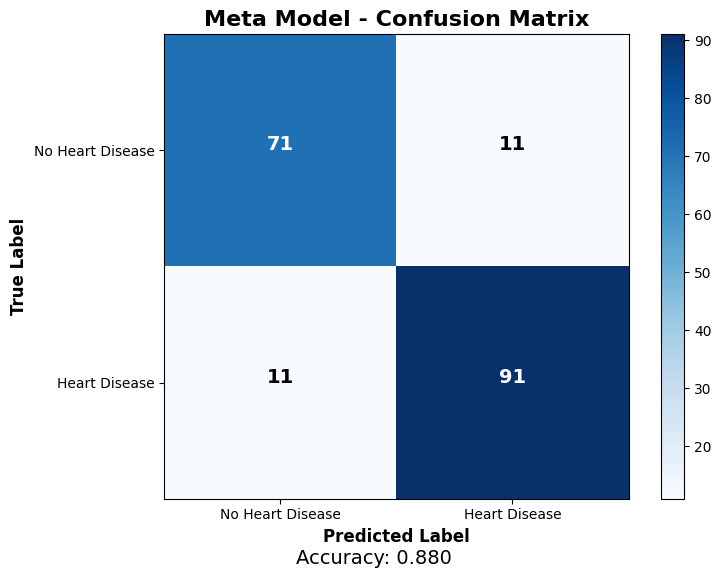


Meta Model Performance:
True Negatives: 71
False Positives: 11
False Negatives: 11
True Positives: 91
Accuracy: 0.880
Precision: 0.892
Recall: 0.892
F1-Score: 0.892


In [117]:
meta_model_cm, meta_model_accuracy = plot_confusion_matrix(y_test, meta_pred, model_name="Meta Model")

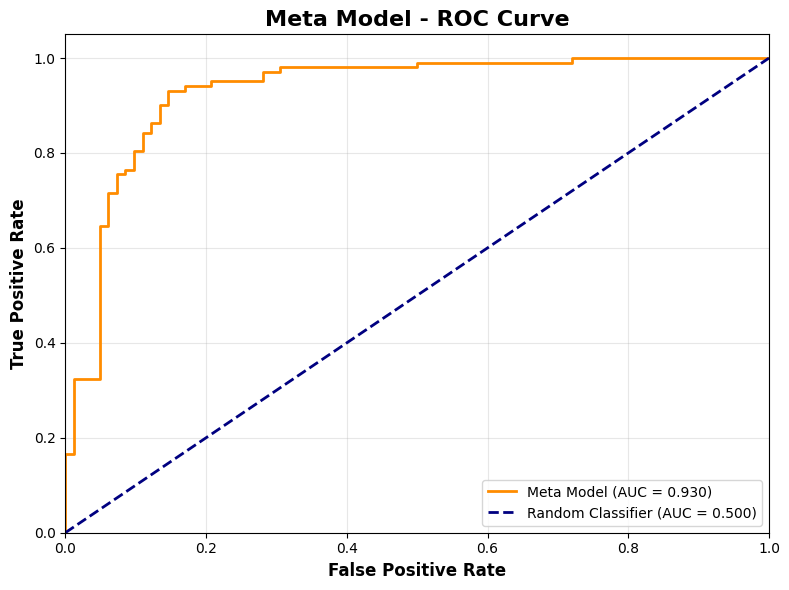


Meta Model ROC AUC Score: 0.930
Excellent performance!


In [118]:
meta_model_fpr, meta_model_tpr, meta_model_threshold = plot_roc_curve(y_test, meta_proba, model_name="Meta Model")

## Meta Model 2

In [119]:
meta_model_2 = XGBClassifier(learning_rate=0.05, n_estimators=200, max_depth=3, eval_metric='logloss', random_state=42, device='cuda')
meta_model_2.fit(meta_X_train, y_train)

meta_pred_2 = meta_model_2.predict(meta_X_test)
meta_proba_2 = meta_model_2.predict_proba(meta_X_test)[:, 1]

In [120]:
print(classification_report(y_test, meta_pred_2))

              precision    recall  f1-score   support

           0       0.82      0.83      0.82        82
           1       0.86      0.85      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



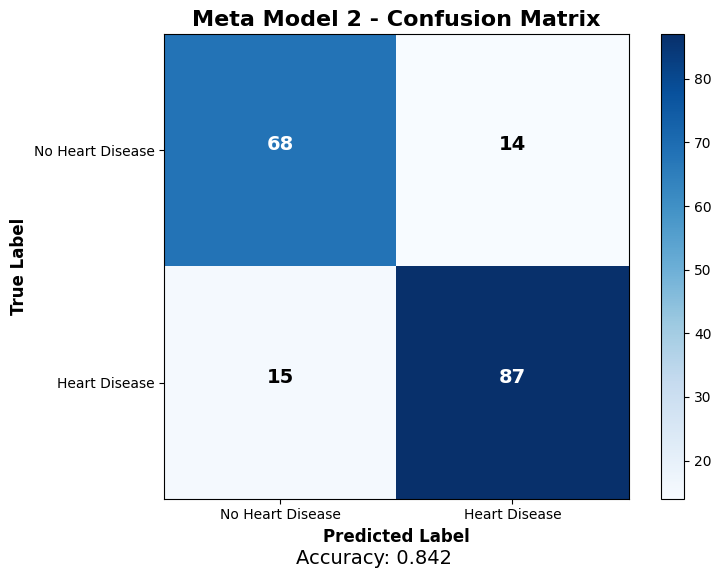


Meta Model 2 Performance:
True Negatives: 68
False Positives: 14
False Negatives: 15
True Positives: 87
Accuracy: 0.842
Precision: 0.861
Recall: 0.853
F1-Score: 0.857


In [121]:
meta_model_cm, meta_model_accuracy = plot_confusion_matrix(y_test, meta_pred_2, model_name="Meta Model 2")

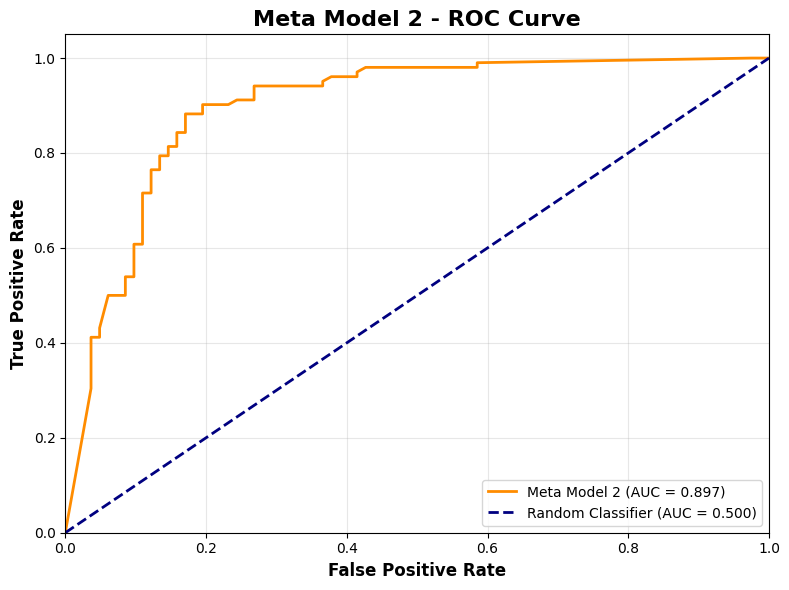


Meta Model 2 ROC AUC Score: 0.897
Good performance!


In [122]:
meta_model_fpr, meta_model_tpr, meta_model_threshold = plot_roc_curve(y_test, meta_proba_2, model_name="Meta Model 2")

# Ensemble model with hyperparameter tuning

## Meta Model 3

In [123]:
# Define meta learner
meta_model = LogisticRegression()

# Define param grid for meta learner
param_grid_log_reg = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'solver': ['liblinear', 'saga'],  # liblinear supports l1/l2, saga supports elasticnet
    'max_iter': [500, 1000],
    'l1_ratio': [0.1, 0.5, 0.9]  # Only used if penalty='elasticnet'
}

# Apply GridSearchCV for tuning
meta_model_3 = GridSearchCV(
    estimator=meta_model,
    param_grid=param_grid_log_reg,
    cv=5,
    scoring='f1',  # especially important for imbalanced data
    verbose=2,
    n_jobs=-1
)

# Fit using the stacked meta features
meta_model_3.fit(meta_X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_

[CV] END C=0.001, l1_ratio=0.1, max_iter=500, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=500, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=500, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=500, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=500, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=1000, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=1000, penal

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_


[CV] END C=0.01, l1_ratio=0.9, max_iter=500, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.01, l1_ratio=0.9, max_iter=500, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.01, l1_ratio=0.9, max_iter=500, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.01, l1_ratio=0.9, max_iter=500, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.01, l1_ratio=0.9, max_iter=500, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END C=0.01, l1_ratio=0.9, max_iter=500, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.1, max_iter=500, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.1, max_iter=500, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.1, max_iter=500, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.1, max_iter=500, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[C

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_


[CV] END C=1, l1_ratio=0.1, max_iter=500, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=1, l1_ratio=0.1, max_iter=500, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=1, l1_ratio=0.1, max_iter=500, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=1, l1_ratio=0.1, max_iter=500, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=1, l1_ratio=0.1, max_iter=500, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=1, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=1, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=1, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=1, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=1, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=1, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=saga;

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_

GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'l1_ratio': [0.1, 0.5, 0.9], 'max_iter': [500, 1000],
                         'penalty': ['l2', 'l1', 'elasticnet'],
                         'solver': ['liblinear', 'saga']},
             scoring='f1', verbose=2)

In [124]:
print("Best Meta Model Params:", meta_model_3.best_params_)
print("Cross-validated F1 Score:", meta_model_3.best_score_)

Best Meta Model Params: {'C': 10, 'l1_ratio': 0.5, 'max_iter': 500, 'penalty': 'elasticnet', 'solver': 'saga'}
Cross-validated F1 Score: 0.9507050052004123


In [125]:
meta_model_3_best = meta_model_3.best_estimator_
meta_model_3_pred = meta_model_3_best.predict(meta_X_test)
meta_model_3_proba = meta_model_3_best.predict_proba(meta_X_test)[:,1]

In [126]:
meta_model_3_best

LogisticRegression(C=10, l1_ratio=0.5, max_iter=500, penalty='elasticnet',
                   solver='saga')

In [127]:
print(classification_report(y_test, meta_model_3_pred))

              precision    recall  f1-score   support

           0       0.83      0.84      0.84        82
           1       0.87      0.86      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



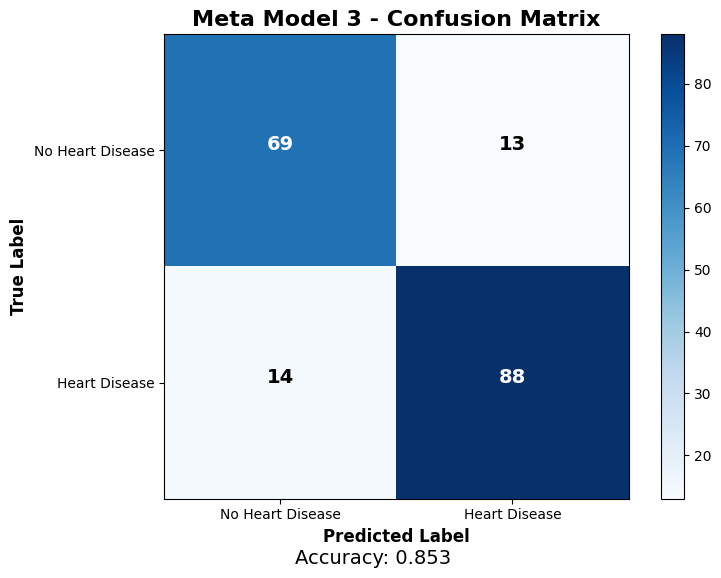


Meta Model 3 Performance:
True Negatives: 69
False Positives: 13
False Negatives: 14
True Positives: 88
Accuracy: 0.853
Precision: 0.871
Recall: 0.863
F1-Score: 0.867


In [128]:
meta_model_3_cm, meta_model_3_acc = plot_confusion_matrix(y_test, meta_model_3_pred, "Meta Model 3")

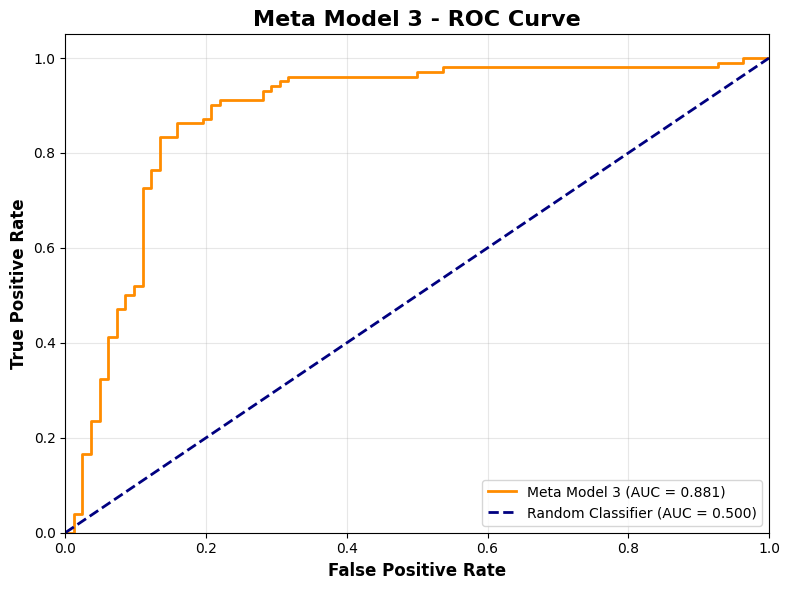


Meta Model 3 ROC AUC Score: 0.881
Good performance!


In [129]:
meta_model_3_fpr, meta_model_3_tpr, meta_model3_threshold = plot_roc_curve(y_test, meta_model_3_proba, "Meta Model 3")

## Meta Model 4

In [130]:
# Define meta learner
meta_model = XGBClassifier()

param_grid_xgb = {
    'n_estimators': [100, 200, 500],          # 3
    'learning_rate': [0.01, 0.1, 0.2],        # 3
    'max_depth': [3, 5, 7],                   # 3
    'subsample': [0.8, 1.0],                  # 2 (reduced from 3)
    'colsample_bytree': [0.7, 0.9],           # 2 (reduced from 3)
    'gamma': [0, 0.2],                        # 2 (reduced from 3)
    'reg_alpha': [0, 0.3],                    # 2 (reduced from 3)
    'reg_lambda': [1, 1.5],                    # 2 (reduced from 3)
    'device' : ['cuda']
}
# Total combinations: 3 × 3 × 3 × 2 × 2 × 2 × 2 × 2 = 1,458

# Apply GridSearchCV for tuning
meta_model_4 = GridSearchCV(
    estimator=meta_model,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='f1',  # especially important for imbalanced data
    verbose=2,
    n_jobs=-1
)

# Fit using the stacked meta features
meta_model_4.fit(meta_X_train, y_train)

Fitting 5 folds for each of 864 candidates, totalling 4320 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [05:16:16] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [05:16:17] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for boo


[CV] END C=10, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=10, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=10, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=10, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=10, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=10, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=10, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=10, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=10, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=10, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=10, l1_ratio=0.1, max_iter=1000, penalty=

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.9], 'device': ['cuda'],
                         'gamma': [0, 0.2], 'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 500], 'reg_alpha': [0, 0.3],
                         'reg_lambda': [1, 1.5], 'subsample': [0.8, 1.0]},
             scoring='f1', verbose=2)

In [131]:
print("Best Meta Model Params:", meta_model_4.best_params_)
print("Cross-validated F1 Score:", meta_model_4.best_score_)

Best Meta Model Params: {'colsample_bytree': 0.7, 'device': 'cuda', 'gamma': 0.2, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'reg_alpha': 0.3, 'reg_lambda': 1.5, 'subsample': 1.0}
Cross-validated F1 Score: 0.9467277479553694


In [132]:
meta_model_4_best = meta_model_4.best_estimator_
meta_model_4_pred = meta_model_4_best.predict(meta_X_test)
meta_model_4_proba = meta_model_4_best.predict_proba(meta_X_test)[:,1]

In [133]:
meta_model_4_best

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.2, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [134]:
print(classification_report(y_test, meta_model_4_pred))

              precision    recall  f1-score   support

           0       0.85      0.87      0.86        82
           1       0.89      0.87      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



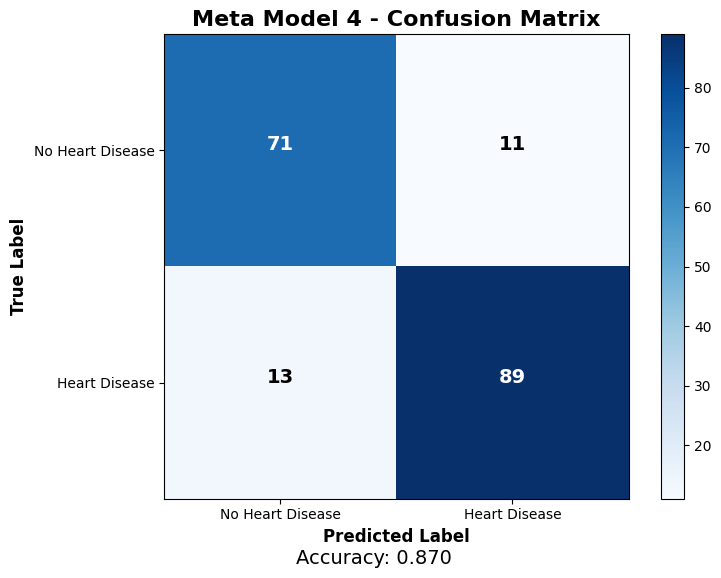


Meta Model 4 Performance:
True Negatives: 71
False Positives: 11
False Negatives: 13
True Positives: 89
Accuracy: 0.870
Precision: 0.890
Recall: 0.873
F1-Score: 0.881


In [135]:
meta_model_4_cm, meta_model_4_acc = plot_confusion_matrix(y_test, meta_model_4_pred, "Meta Model 4")

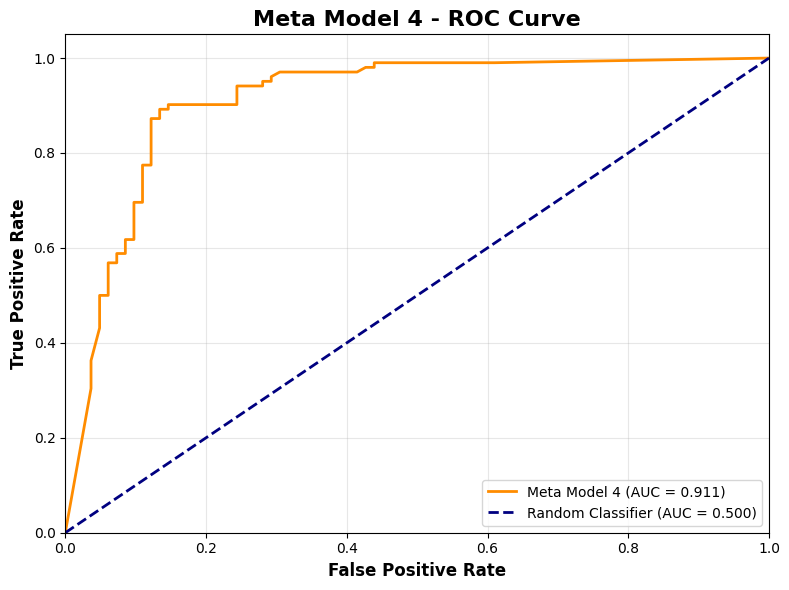


Meta Model 4 ROC AUC Score: 0.911
Excellent performance!


In [136]:
meta_model_4_fpr, meta_model_4_tpr, meta_model4_threshold = plot_roc_curve(y_test, meta_model_4_proba, "Meta Model 4")

# Ensemble Model with Stratified K-folds

## Meta Model 5

In [137]:
# Define meta learner
meta_model = LogisticRegression()

# Define param grid for meta learner
param_grid_log_reg = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'solver': ['liblinear', 'saga'],  # liblinear supports l1/l2, saga supports elasticnet
    'max_iter': [500, 1000],
    'l1_ratio': [0.1, 0.5, 0.9]  # Only used if penalty='elasticnet'
}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Apply GridSearchCV for tuning
meta_model_5 = GridSearchCV(
    estimator=meta_model,
    param_grid=param_grid_log_reg,
    cv=skf,
    scoring='f1',  # especially important for imbalanced data
    verbose=2,
    n_jobs=-1
)

# Fit using the stacked meta features
meta_model_5.fit(meta_X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

[CV] END colsample_bytree=0.9, device=cuda, gamma=0.2, learning_rate=0.2, max_depth=5, n_estimators=200, reg_alpha=0, reg_lambda=1.5, subsample=1.0; total time=   1.4s
[CV] END colsample_bytree=0.9, device=cuda, gamma=0.2, learning_rate=0.2, max_depth=5, n_estimators=200, reg_alpha=0.3, reg_lambda=1, subsample=0.8; total time=   1.5s
[CV] END colsample_bytree=0.9, device=cuda, gamma=0.2, learning_rate=0.2, max_depth=5, n_estimators=200, reg_alpha=0.3, reg_lambda=1, subsample=0.8; total time=   1.4s
[CV] END colsample_bytree=0.9, device=cuda, gamma=0.2, learning_rate=0.2, max_depth=5, n_estimators=200, reg_alpha=0.3, reg_lambda=1, subsample=1.0; total time=   1.3s
[CV] END colsample_bytree=0.9, device=cuda, gamma=0.2, learning_rate=0.2, max_depth=5, n_estimators=200, reg_alpha=0.3, reg_lambda=1.5, subsample=0.8; total time=   1.5s
[CV] END colsample_bytree=0.9, device=cuda, gamma=0.2, learning_rate=0.2, max_depth=5, n_esti

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_


[CV] END C=0.001, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=1000, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=1000, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=1000, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=1000, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.5, max_iter=500, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.5, max_iter=500, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.5, max_iter=500, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.5, max_iter=500, penalty=l2, solver=

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_


[CV] END C=0.01, l1_ratio=0.5, max_iter=1000, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.1, max_iter=500, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.1, max_iter=500, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.1, max_iter=500, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.1, max_iter=500, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.1, max_iter=500, penalty=

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_


[CV] END C=1, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=1, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=1, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=1, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=1, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=1, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=1, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=1, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=10, l1_ratio=0.1, max_iter=1000, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END C=10, l1_ratio=0.1, max_iter=1000, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END C=10, l1_ratio=0.1, max_ite

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning: 
180 fits failed out of a total of 1080.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
180 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py", line 1162, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.p

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'l1_ratio': [0.1, 0.5, 0.9], 'max_iter': [500, 1000],
                         'penalty': ['l2', 'l1', 'elasticnet'],
                         'solver': ['liblinear', 'saga']},
             scoring='f1', verbose=2)

In [138]:
print("Best Meta Model Params:", meta_model_5.best_params_)
print("Cross-validated F1 Score:", meta_model_5.best_score_)

Best Meta Model Params: {'C': 10, 'l1_ratio': 0.9, 'max_iter': 500, 'penalty': 'elasticnet', 'solver': 'saga'}
Cross-validated F1 Score: 0.9493864287154856


In [139]:
meta_model_5_best = meta_model_5.best_estimator_
meta_model_5_pred = meta_model_5_best.predict(meta_X_test)
meta_model_5_proba = meta_model_5_best.predict_proba(meta_X_test)[:,1]

In [140]:
meta_model_5_best

LogisticRegression(C=10, l1_ratio=0.9, max_iter=500, penalty='elasticnet',
                   solver='saga')

In [141]:
print(classification_report(y_test, meta_model_5_pred))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80        82
           1       0.84      0.84      0.84       102

    accuracy                           0.83       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184



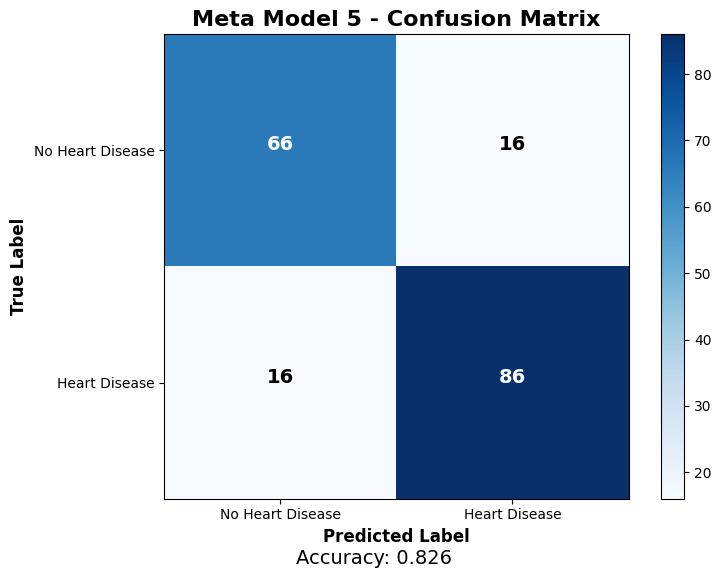


Meta Model 5 Performance:
True Negatives: 66
False Positives: 16
False Negatives: 16
True Positives: 86
Accuracy: 0.826
Precision: 0.843
Recall: 0.843
F1-Score: 0.843


In [142]:
meta_model_5_cm, meta_model_5_acc = plot_confusion_matrix(y_test, meta_model_5_pred, "Meta Model 5")

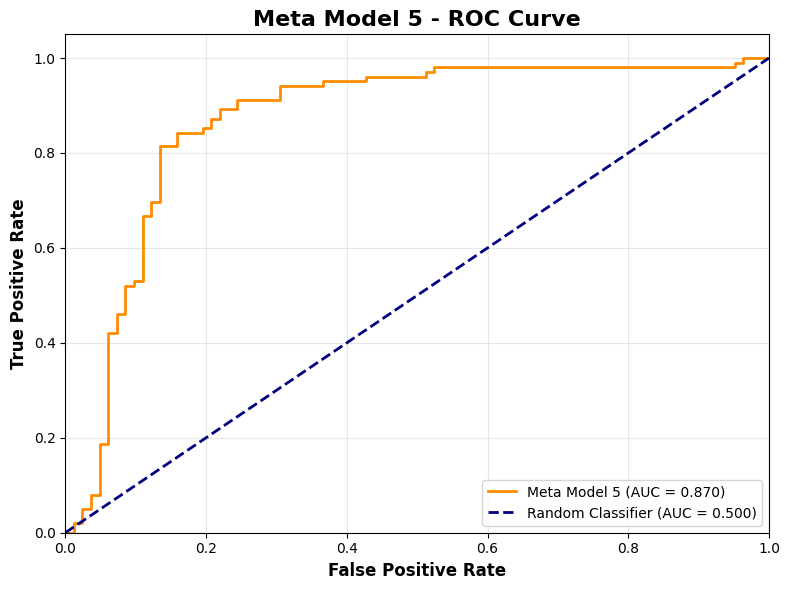


Meta Model 5 ROC AUC Score: 0.870
Good performance!


In [143]:
meta_model_5_fpr, meta_model_5_tpr, meta_model5_threshold = plot_roc_curve(y_test, meta_model_5_proba, "Meta Model 5")

## Meta Model 6

In [144]:
# Define meta learner
meta_model = XGBClassifier()

param_grid_xgb = {
    'n_estimators': [100, 200, 500],          # 3
    'learning_rate': [0.01, 0.1, 0.2],        # 3
    'max_depth': [3, 5, 7],                   # 3
    'subsample': [0.8, 1.0],                  # 2 (reduced from 3)
    'colsample_bytree': [0.7, 0.9],           # 2 (reduced from 3)
    'gamma': [0, 0.2],                        # 2 (reduced from 3)
    'reg_alpha': [0, 0.3],                    # 2 (reduced from 3)
    'reg_lambda': [1, 1.5],                    # 2 (reduced from 3)
    'device' : ['cuda']
}
# Total combinations: 3 × 3 × 3 × 2 × 2 × 2 × 2 × 2 = 1,458

# Apply GridSearchCV for tuning
meta_model_6 = GridSearchCV(
    estimator=meta_model,
    param_grid=param_grid_xgb,
    cv=skf,
    scoring='f1',  # especially important for imbalanced data
    verbose=2,
    n_jobs=-1
)

# Fit using the stacked meta features
meta_model_6.fit(meta_X_train, y_train)

Fitting 5 folds for each of 864 candidates, totalling 4320 fits

[CV] END C=1, l1_ratio=0.5, max_iter=500, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=1, l1_ratio=0.5, max_iter=500, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=1, l1_ratio=0.5, max_iter=500, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=1, l1_ratio=0.5, max_iter=500, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=1, l1_ratio=0.5, max_iter=500, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=1, l1_ratio=0.5, max_iter=1000, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=1, l1_ratio=0.5, max_iter=1000, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=10, l1_ratio=0.5, max_iter=1000, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END C=10, l1_ratio=0.5, max_iter=1000, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=10, l1_ratio=0.5, max_iter=1000, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=1

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_typ...
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.9], 'device': ['cuda'],
                         'gamma': [0, 0.2], 'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 500], 'reg_alpha': [0, 0.3],
                         'reg_lambda': [1, 1.5], 'subsample': [0.8, 1.0]},
             scoring='f1', verbose=2)

In [145]:
print("Best Meta Model Params:", meta_model_6.best_params_)
print("Cross-validated F1 Score:", meta_model_6.best_score_)

Best Meta Model Params: {'colsample_bytree': 0.7, 'device': 'cuda', 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 1.0}
Cross-validated F1 Score: 0.9358357938905769


In [146]:
meta_model_6_best = meta_model_6.best_estimator_
meta_model_6_pred = meta_model_6_best.predict(meta_X_test)
meta_model_6_proba = meta_model_6_best.predict_proba(meta_X_test)[:,1]

In [147]:
meta_model_6_best

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [148]:
print(classification_report(y_test, meta_model_6_pred))

              precision    recall  f1-score   support

           0       0.82      0.83      0.82        82
           1       0.86      0.85      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



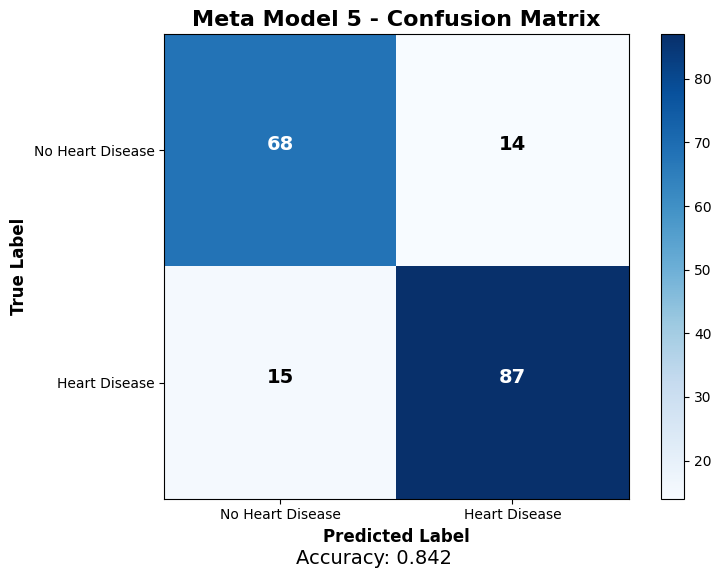


Meta Model 5 Performance:
True Negatives: 68
False Positives: 14
False Negatives: 15
True Positives: 87
Accuracy: 0.842
Precision: 0.861
Recall: 0.853
F1-Score: 0.857


In [149]:
meta_model_6_cm, meta_model_6_acc = plot_confusion_matrix(y_test, meta_model_6_pred, "Meta Model 5")

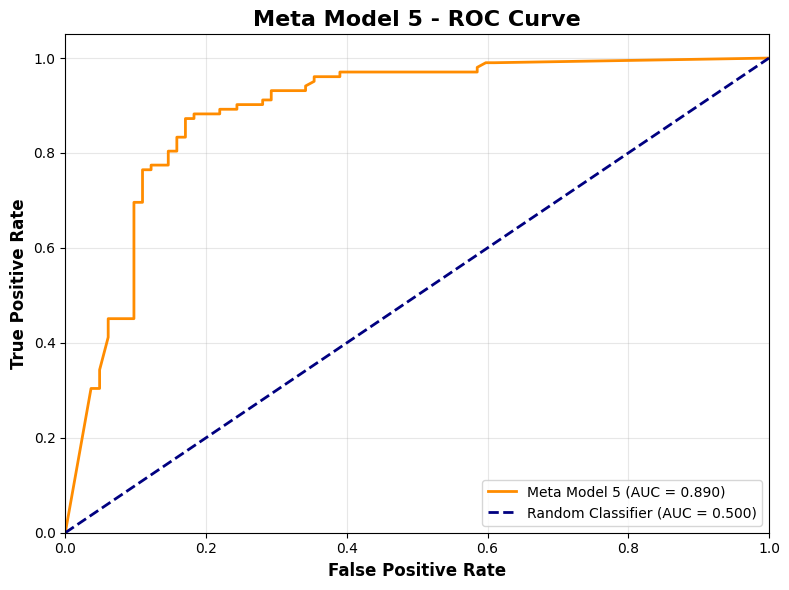


Meta Model 5 ROC AUC Score: 0.890
Good performance!


In [150]:
meta_model_6_fpr, meta_model_6_tpr, meta_model6_threshold = plot_roc_curve(y_test, meta_model_6_proba, "Meta Model 5")

# Ensemble with xgboost

## Meta Model 7

In [151]:
xgb_ensemble = XGBClassifier(colsample_bytree=1.0,
                              device='cuda',
                              gamma=0.1,
                              learning_rate=0.1,
                              max_depth=3,
                              n_estimators=100,
                              random_state=42,
                              reg_alpha=0.1,
                              reg_lambda=2,
                              scale_pos_weight=1,
                              subsample=0.8,
                              tree_method='hist')
xgb_ensemble.fit(X_train, y_train)

# Use predicted probabilities as input features to meta learner
xgb_pred_train = xgb_ensemble.predict_proba(X_train)[:, 1]
xgb_pred_test = xgb_ensemble.predict_proba(X_test)[:, 1]

# Stack them horizontally as new features
meta_X_train_2 = np.column_stack((xgb_pred_train, tree_pred_train, linear_pred_train))
meta_X_test_2 = np.column_stack((xgb_pred_test, tree_pred_test, linear_pred_test))

In [152]:
# Define meta learner
meta_model = LogisticRegression()

# Define param grid for meta learner
param_grid_log_reg = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'solver': ['liblinear', 'saga'],  # liblinear supports l1/l2, saga supports elasticnet
    'max_iter': [500, 1000],
    'l1_ratio': [0.1, 0.5, 0.9]  # Only used if penalty='elasticnet'
}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Apply GridSearchCV for tuning
meta_model_7 = GridSearchCV(
    estimator=meta_model,
    param_grid=param_grid_log_reg,
    cv=skf,
    scoring='roc_auc',  # especially important for imbalanced data
    verbose=2,
    n_jobs=-1
)

# Fit using the stacked meta features
meta_model_7.fit(meta_X_train_2, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

[CV] END colsample_bytree=0.9, device=cuda, gamma=0.2, learning_rate=0.2, max_depth=5, n_estimators=500, reg_alpha=0, reg_lambda=1, subsample=1.0; total time=   2.7s
[CV] END colsample_bytree=0.9, device=cuda, gamma=0.2, learning_rate=0.2, max_depth=5, n_estimators=500, reg_alpha=0, reg_lambda=1, subsample=1.0; total time=   2.7s
[CV] END colsample_bytree=0.9, device=cuda, gamma=0.2, learning_rate=0.2, max_depth=5, n_estimators=500, reg_alpha=0, reg_lambda=1.5, subsample=0.8; total time=   3.4s
[CV] END colsample_bytree=0.9, device=cuda, gamma=0.2, learning_rate=0.2, max_depth=5, n_estimators=500, reg_alpha=0, reg_lambda=1.5, subsample=1.0; total time=   2.7s
[CV] END colsample_bytree=0.9, device=cuda, gamma=0.2, learning_rate=0.2, max_depth=5, n_estimators=500, reg_alpha=0.3, reg_lambda=1, subsample=0.8; total time=   3.3s
[CV] END colsample_bytree=0.9, device=cuda, gamma=0.2, learning_rate=0.2, max_depth=5, n_estimators

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_


[CV] END colsample_bytree=0.9, device=cuda, gamma=0.2, learning_rate=0.2, max_depth=7, n_estimators=500, reg_alpha=0.3, reg_lambda=1.5, subsample=1.0; total time=   2.7s
[CV] END C=0.001, l1_ratio=0.1, max_iter=500, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=500, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=500, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=500, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=500, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=500, pena

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_


[CV] END C=0.1, l1_ratio=0.9, max_iter=500, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.9, max_iter=500, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.9, max_iter=500, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.9, max_iter=500, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.9, max_iter=500, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.9, max_iter=500, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.9, max_iter=500, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.9, max_iter=500, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.9, max_iter=500, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.9, max_iter=500, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.9, max_iter=500, penalty=l1, solver=liblinear; total time=   0.0s
[

...


[CV] END C=0.1, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.1, max_iter=1000, penalty=l2, solver

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_


[CV] END C=1, l1_ratio=0.9, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=1, l1_ratio=0.9, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=1, l1_ratio=0.9, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=1, l1_ratio=0.9, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=1, l1_ratio=0.9, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=1, l1_ratio=0.9, max_iter=500, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=1, l1_ratio=0.9, max_iter=500, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=1, l1_ratio=0.9, max_iter=500, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=1, l1_ratio=0.9, max_iter=500, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=1, l1_ratio=0.9, max_iter=500, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=1, l1_ratio=0.9, max_it

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'l1_ratio': [0.1, 0.5, 0.9], 'max_iter': [500, 1000],
                         'penalty': ['l2', 'l1', 'elasticnet'],
                         'solver': ['liblinear', 'saga']},
             scoring='roc_auc', verbose=2)

In [153]:
print("Best Meta Model Params:", meta_model_7.best_params_)
print("Cross-validated ROC Score:", meta_model_7.best_score_)

Best Meta Model Params: {'C': 10, 'l1_ratio': 0.1, 'max_iter': 500, 'penalty': 'l1', 'solver': 'liblinear'}
Cross-validated ROC Score: 0.9878107459137269


In [154]:
meta_model_7_best = meta_model_7.best_estimator_
meta_model_7_pred = meta_model_7_best.predict(meta_X_test_2)
meta_model_7_proba = meta_model_7_best.predict_proba(meta_X_test_2)[:,1]

In [155]:
meta_model_7_best

LogisticRegression(C=10, l1_ratio=0.1, max_iter=500, penalty='l1',
                   solver='liblinear')

In [156]:
print(classification_report(y_test, meta_model_7_pred))

              precision    recall  f1-score   support

           0       0.81      0.84      0.83        82
           1       0.87      0.84      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



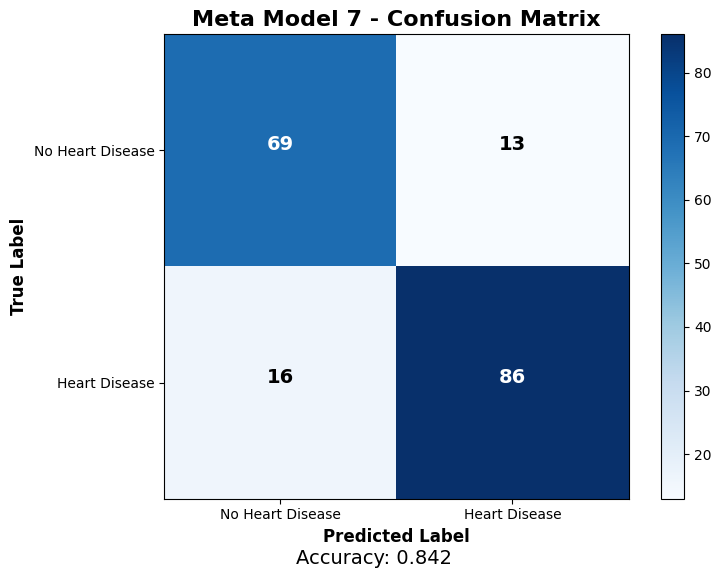


Meta Model 7 Performance:
True Negatives: 69
False Positives: 13
False Negatives: 16
True Positives: 86
Accuracy: 0.842
Precision: 0.869
Recall: 0.843
F1-Score: 0.856


In [157]:
meta_model_7_cm, meta_model_7_acc = plot_confusion_matrix(y_test, meta_model_7_pred, "Meta Model 7")

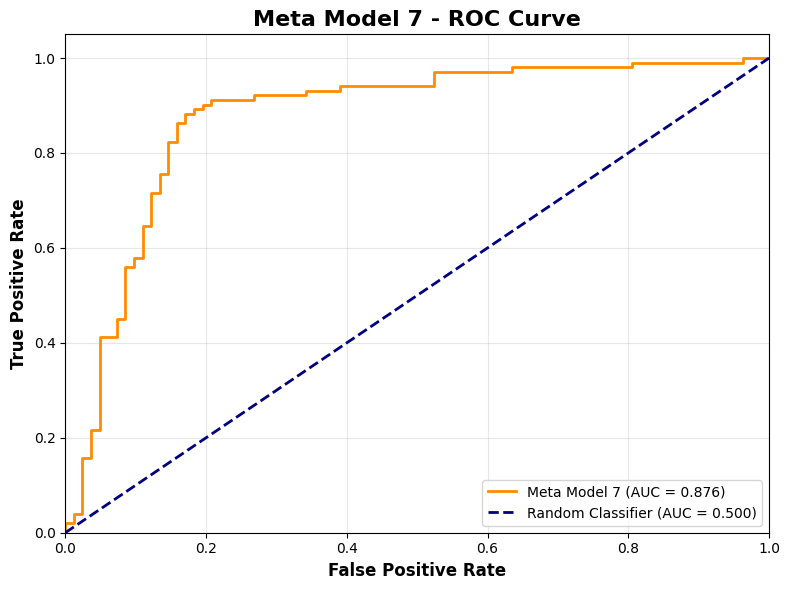


Meta Model 7 ROC AUC Score: 0.876
Good performance!


In [158]:
meta_model_7_fpr, meta_model_7_tpr, meta_model7_threshold = plot_roc_curve(y_test, meta_model_7_proba, "Meta Model 7")

# Ensemble with lightGBM

## Meta Model 8

In [159]:
lightgbm_ensemble = LGBMClassifier(class_weight=None,
                                 colsample_bytree=0.8,
                                 device='gpu',
                                 learning_rate=0.01,
                                 max_depth=-1,
                                 min_child_samples=50,
                                 n_estimators=500,
                                 num_leaves=31,
                                 random_state=42,
                                 reg_alpha=0,
                                 reg_lambda=0,
                                 subsample=0.8,
                                 verbose=-1)
lightgbm_ensemble.fit(X_train, y_train)

# Use predicted probabilities as input features to meta learner
lgb_pred_train = lightgbm_ensemble.predict_proba(X_train)[:, 1]
lgb_pred_test = lightgbm_ensemble.predict_proba(X_test)[:, 1]

# Stack them horizontally as new features
meta_X_train_3 = np.column_stack((lgb_pred_train, tree_pred_train, linear_pred_train))
meta_X_test_3 = np.column_stack((lgb_pred_test, tree_pred_test, linear_pred_test))

In [160]:
# Define meta learner
meta_model = LogisticRegression()

# Define param grid for meta learner
param_grid_log_reg = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'solver': ['liblinear', 'saga'],  # liblinear supports l1/l2, saga supports elasticnet
    'max_iter': [500, 1000],
    'l1_ratio': [0.1, 0.5, 0.9]  # Only used if penalty='elasticnet'
}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Apply GridSearchCV for tuning
meta_model_8 = GridSearchCV(
    estimator=meta_model,
    param_grid=param_grid_log_reg,
    cv=skf,
    scoring='roc_auc',  # especially important for imbalanced data
    verbose=2,
    n_jobs=-1
)

# Fit using the stacked meta features
meta_model_8.fit(meta_X_train_3, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

[CV] END C=10, l1_ratio=0.5, max_iter=1000, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=10, l1_ratio=0.5, max_iter=1000, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=10, l1_ratio=0.5, max_iter=1000, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=10, l1_ratio=0.5, max_iter=1000, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=10, l1_ratio=0.5, max_iter=1000, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=10, l1_ratio=0.5, max_iter=1000, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=10, l1_ratio=0.5, max_iter=1000, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=10, l1_ratio=0.5, max_iter=1000, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=10, l1_ratio=0.9, max_iter=500, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=10, l1_ratio=0.9, max_iter=500, penalty=l2, solve

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_


[CV] END C=100, l1_ratio=0.9, max_iter=1000, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=500, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=500, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=500, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=500, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.001, l1_ratio=0.1, max_iter=1000, penalt

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_


[CV] END C=0.01, l1_ratio=0.9, max_iter=1000, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.01, l1_ratio=0.9, max_iter=1000, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.01, l1_ratio=0.9, max_iter=1000, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.01, l1_ratio=0.9, max_iter=1000, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.01, l1_ratio=0.9, max_iter=1000, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.01, l1_ratio=0.9, max_iter=1000, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.01, l1_ratio=0.9, max_iter=1000, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.01, l1_ratio=0.9, max_iter=1000, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.01, l1_ratio=0.9, max_iter=1000, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END C=0.01, l1_ratio=0.9, max_iter=1000, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END C=0.01, l1_ratio=0.9, max_iter=1000, penalty=l1, solver=liblinear

...


[CV] END C=0.1, l1_ratio=0.9, max_iter=500, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.9, max_iter=500, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.9, max_iter=500, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.9, max_iter=500, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.9, max_iter=500, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.9, max_iter=500, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.9, max_iter=500, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.9, max_iter=500, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.9, max_iter=500, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.9, max_iter=500, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.1, l1_ratio=0.9, max_iter=500, penalty=l1, solver=liblinear; total time=   0.0s
[

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_


[CV] END C=1, l1_ratio=0.5, max_iter=500, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END C=1, l1_ratio=0.5, max_iter=500, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END C=1, l1_ratio=0.5, max_iter=500, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=1, l1_ratio=0.5, max_iter=500, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=1, l1_ratio=0.5, max_iter=500, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=1, l1_ratio=0.5, max_iter=500, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=1, l1_ratio=0.5, max_iter=500, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=1, l1_ratio=0.5, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=1, l1_ratio=0.5, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=1, l1_ratio=0.5, max_iter=500, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=1, l1_ratio=0.5, max_iter=500, penalty=elasticnet, solver=liblinear; total time

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'l1_ratio': [0.1, 0.5, 0.9], 'max_iter': [500, 1000],
                         'penalty': ['l2', 'l1', 'elasticnet'],
                         'solver': ['liblinear', 'saga']},
             scoring='roc_auc', verbose=2)

In [161]:
print("Best Meta Model Params:", meta_model_8.best_params_)
print("Cross-validated ROC Score:", meta_model_8.best_score_)

Best Meta Model Params: {'C': 10, 'l1_ratio': 0.1, 'max_iter': 500, 'penalty': 'l1', 'solver': 'saga'}
Cross-validated ROC Score: 0.9888954446136019


In [162]:
meta_model_8_best = meta_model_8.best_estimator_
meta_model_8_pred = meta_model_8_best.predict(meta_X_test_3)
meta_model_8_proba = meta_model_8_best.predict_proba(meta_X_test_3)[:,1]

In [163]:
meta_model_8_best

LogisticRegression(C=10, l1_ratio=0.1, max_iter=500, penalty='l1',
                   solver='saga')

In [164]:
print(classification_report(y_test, meta_model_8_pred))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80        82
           1       0.84      0.84      0.84       102

    accuracy                           0.83       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184



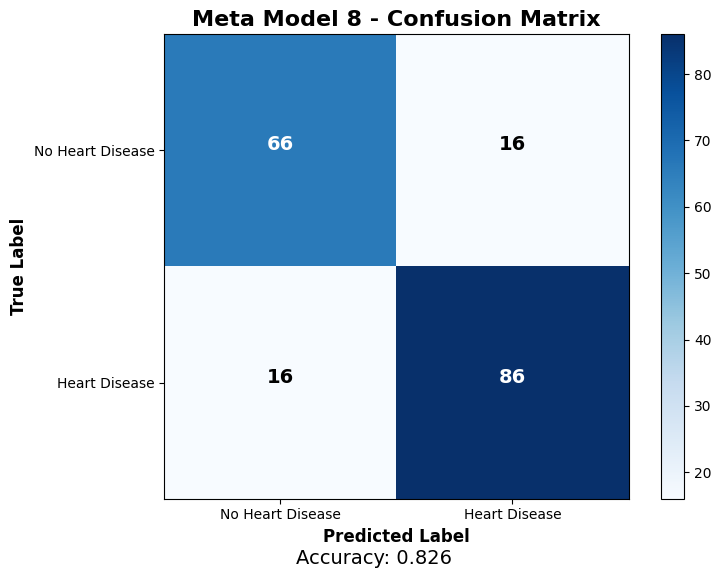


Meta Model 8 Performance:
True Negatives: 66
False Positives: 16
False Negatives: 16
True Positives: 86
Accuracy: 0.826
Precision: 0.843
Recall: 0.843
F1-Score: 0.843


In [165]:
meta_model_8_cm, meta_model_8_acc = plot_confusion_matrix(y_test, meta_model_8_pred, "Meta Model 8")

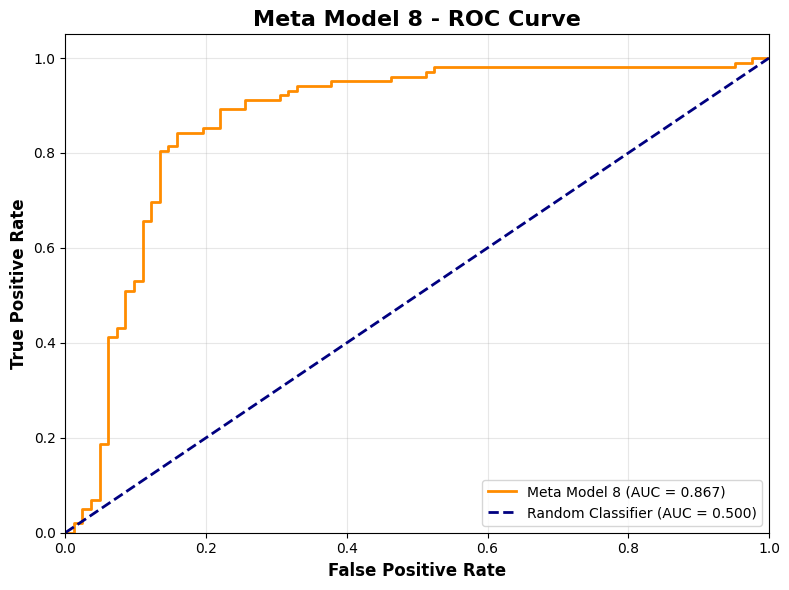


Meta Model 8 ROC AUC Score: 0.867
Good performance!


In [166]:
meta_model_8_fpr, meta_model_8_tpr, meta_model8_threshold = plot_roc_curve(y_test, meta_model_8_proba, "Meta Model 8")

# Ensemble with lightGBM and no hyperparameter tuning

## Meta Model 9

In [167]:
meta_model_9 = LogisticRegression(max_iter=1000, random_state=42)
meta_model_9.fit(meta_X_train_3, y_train)

meta_pred_9 = meta_model_9.predict(meta_X_test_3)
meta_proba_9 = meta_model_9.predict_proba(meta_X_test_3)[:, 1]

In [168]:
print(classification_report(y_test, meta_pred_9))

              precision    recall  f1-score   support

           0       0.88      0.88      0.88        82
           1       0.90      0.90      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



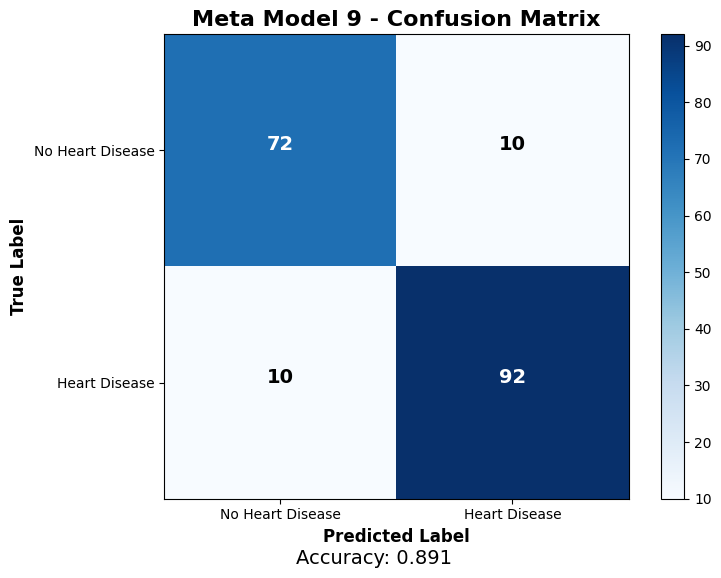


Meta Model 9 Performance:
True Negatives: 72
False Positives: 10
False Negatives: 10
True Positives: 92
Accuracy: 0.891
Precision: 0.902
Recall: 0.902
F1-Score: 0.902


In [169]:
meta_model_9_cm, meta_model_9_accuracy = plot_confusion_matrix(y_test, meta_pred_9, model_name="Meta Model 9")

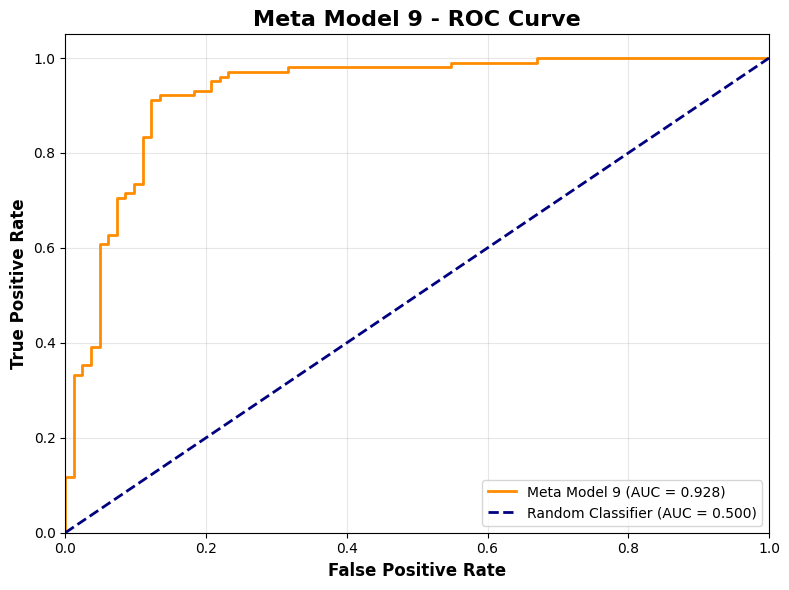


Meta Model 9 ROC AUC Score: 0.928
Excellent performance!


In [170]:
meta_model_9_fpr, meta_model_9_tpr, meta_model9_threshold = plot_roc_curve(y_test, meta_proba_9, model_name="Meta Model 9")

In [171]:
model_9_score = cross_val_score(meta_model_9, meta_X_train_3, y_train, cv=5, scoring='roc_auc')

In [172]:
model_9_score

array([0.99380863, 0.98391321, 0.98204265, 0.97493453, 0.96562203])

# Ensemble with Weights

## Meta Model 10

In [173]:
tree_ensemble_2 = VotingClassifier(
    estimators=[
        ('dt', DecisionTreeClassifier(criterion='gini',
                                      max_depth=5,
                                      min_samples_split=2,
                                      min_samples_leaf=5,
                                      max_features=None,
                                      class_weight=None,
                                      random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=300,
                                      criterion='gini',
                                      max_depth=None,
                                      min_samples_split=5,
                                      min_samples_leaf=2,
                                      max_features='sqrt',
                                      bootstrap=True,
                                      n_jobs=-1,
                                      random_state=42)),
        ('xgb', XGBClassifier(colsample_bytree=1.0,
                              device='cuda',
                              gamma=0.1,
                              learning_rate=0.1,
                              max_depth=3,
                              n_estimators=100,
                              random_state=42,
                              reg_alpha=0.1,
                              reg_lambda=2,
                              scale_pos_weight=1,
                              subsample=0.8,
                              tree_method='hist')),
        ('lgbm', LGBMClassifier(class_weight=None,
                                 colsample_bytree=0.8,
                                 device='gpu',
                                 learning_rate=0.01,
                                 max_depth=-1,
                                 min_child_samples=50,
                                 n_estimators=500,
                                 num_leaves=31,
                                 random_state=42,
                                 reg_alpha=0,
                                 reg_lambda=0,
                                 subsample=0.8,
                                 verbose=-1))
    ],
    voting='soft',  # Use probabilities for smoother averaging
    weights=[8.85,8.70,8.88,8.81],
    n_jobs=-1
)

In [174]:
linear_ensemble_2 = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(C=0.1, max_iter=100, penalty='l2', random_state=42, solver='saga')),
        ('knn', KNeighborsClassifier(leaf_size=20, metric='minkowski', n_neighbors=7, p=1, weights='uniform')),
        ('svc', SVC(C=0.1, class_weight=None, degree=2, gamma='scale', kernel='rbf', probability=True, random_state=42))
    ],
    voting='soft',
    weights=[8.44,8.74,8.30],
    n_jobs=-1
)

In [175]:
tree_ensemble_2.fit(X_train, y_train)
linear_ensemble_2.fit(X_train, y_train)


[CV] END C=10, l1_ratio=0.9, max_iter=1000, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=10, l1_ratio=0.9, max_iter=1000, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=10, l1_ratio=0.9, max_iter=1000, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=10, l1_ratio=0.9, max_iter=1000, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=10, l1_ratio=0.9, max_iter=1000, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END C=10, l1_ratio=0.9, max_iter=1000, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=10, l1_ratio=0.9, max_iter=1000, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=10, l1_ratio=0.9, max_iter=1000, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=10, l1_ratio=0.9, max_iter=1000, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=10, l1_ratio=0.9, max_iter=1000, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=100

VotingClassifier(estimators=[('lr',
                              LogisticRegression(C=0.1, random_state=42,
                                                 solver='saga')),
                             ('knn',
                              KNeighborsClassifier(leaf_size=20, n_neighbors=7,
                                                   p=1)),
                             ('svc',
                              SVC(C=0.1, degree=2, probability=True,
                                  random_state=42))],
                 n_jobs=-1, voting='soft', weights=[8.44, 8.74, 8.3])

In [176]:
# Use predicted probabilities as input features to meta learner
tree_pred_train_2 = tree_ensemble_2.predict_proba(X_train)[:, 1]
linear_pred_train_2 = linear_ensemble_2.predict_proba(X_train)[:, 1]

tree_pred_test_2 = tree_ensemble_2.predict_proba(X_test)[:, 1]
linear_pred_test_2 = linear_ensemble_2.predict_proba(X_test)[:, 1]

# Stack them horizontally as new features
meta_X_train_4 = np.column_stack((lgb_pred_train, tree_pred_train_2, linear_pred_train_2))
meta_X_test_4 = np.column_stack((lgb_pred_test, tree_pred_test_2, linear_pred_test_2))

In [177]:
meta_model_10 = LogisticRegression(max_iter=1000, random_state=42)
meta_model_10.fit(meta_X_train_4, y_train)

meta_pred_10 = meta_model_10.predict(meta_X_test_4)
meta_proba_10 = meta_model_10.predict_proba(meta_X_test_4)[:, 1]

In [178]:
print(classification_report(y_test, meta_pred_10))

              precision    recall  f1-score   support

           0       0.88      0.88      0.88        82
           1       0.90      0.90      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



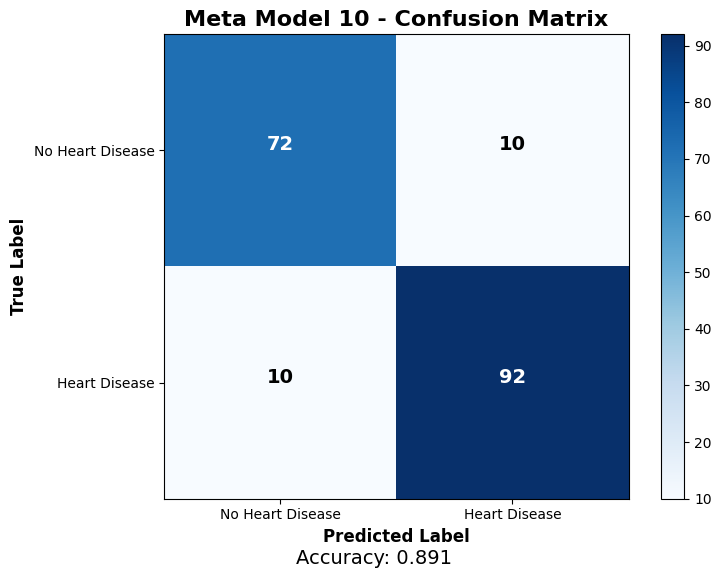


Meta Model 10 Performance:
True Negatives: 72
False Positives: 10
False Negatives: 10
True Positives: 92
Accuracy: 0.891
Precision: 0.902
Recall: 0.902
F1-Score: 0.902


In [179]:
meta_model_10_cm, meta_model_10_accuracy = plot_confusion_matrix(y_test, meta_pred_10, model_name="Meta Model 10")

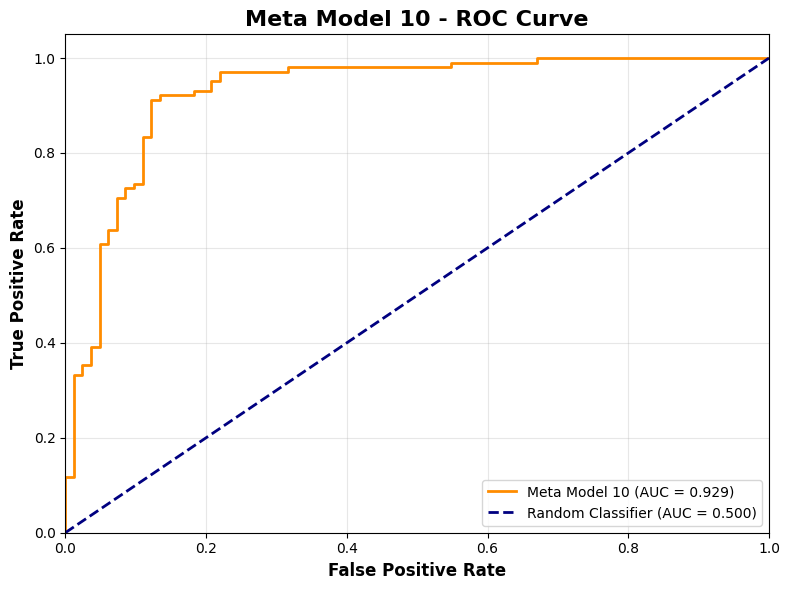


Meta Model 10 ROC AUC Score: 0.929
Excellent performance!


In [180]:
meta_model_10_fpr, meta_model_10_tpr, meta_model10_threshold = plot_roc_curve(y_test, meta_proba_10, model_name="Meta Model 10")

# Ensemble with Catboost

## Meta Model 11

In [181]:
catboost_ensemble = CatBoostClassifier(task_type='GPU',random_state=42)
catboost_ensemble.fit(X_train, y_train)

# Use predicted probabilities as input features to meta learner
catboost_pred_train = catboost_ensemble.predict_proba(X_train)[:, 1]
catboost_pred_test = catboost_ensemble.predict_proba(X_test)[:, 1]

# Stack them horizontally as new features
meta_X_train_5 = np.column_stack((catboost_pred_train, tree_pred_train, linear_pred_train))
meta_X_test_5 = np.column_stack((catboost_pred_test, tree_pred_test, linear_pred_test))

Learning rate set to 0.034289
0:	learn: 0.6709265	total: 16.4ms	remaining: 16.4s
1:	learn: 0.6447073	total: 39.4ms	remaining: 19.7s
2:	learn: 0.6246591	total: 53.6ms	remaining: 17.8s
3:	learn: 0.6025480	total: 86.1ms	remaining: 21.4s
4:	learn: 0.5839364	total: 102ms	remaining: 20.2s
5:	learn: 0.5633812	total: 135ms	remaining: 22.3s
6:	learn: 0.5480207	total: 151ms	remaining: 21.4s
7:	learn: 0.5350405	total: 165ms	remaining: 20.4s
8:	learn: 0.5184479	total: 187ms	remaining: 20.6s
9:	learn: 0.5068782	total: 219ms	remaining: 21.7s
10:	learn: 0.4973601	total: 235ms	remaining: 21.1s
11:	learn: 0.4841323	total: 265ms	remaining: 21.8s
12:	learn: 0.4717654	total: 297ms	remaining: 22.5s
13:	learn: 0.4665173	total: 310ms	remaining: 21.8s
14:	learn: 0.4572272	total: 327ms	remaining: 21.5s
15:	learn: 0.4454532	total: 349ms	remaining: 21.4s
16:	learn: 0.4351397	total: 379ms	remaining: 21.9s
17:	learn: 0.4284206	total: 410ms	remaining: 22.4s
18:	learn: 0.4180031	total: 440ms	remaining: 22.7s
19:	lea

In [182]:
meta_model_11 = LogisticRegression(max_iter=1000, random_state=42)
meta_model_11.fit(meta_X_train_5, y_train)

meta_pred_11 = meta_model_11.predict(meta_X_test_5)
meta_proba_11 = meta_model_11.predict_proba(meta_X_test_5)[:, 1]

In [183]:
print(classification_report(y_test, meta_pred_11))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86        82
           1       0.90      0.86      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



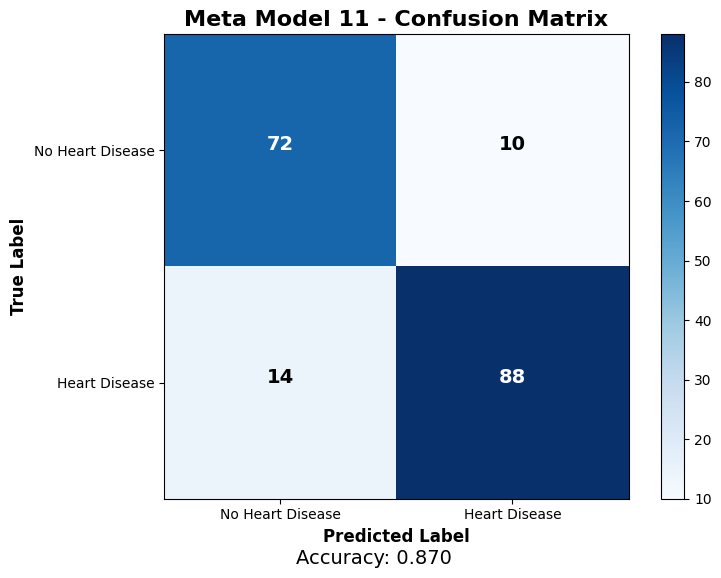


Meta Model 11 Performance:
True Negatives: 72
False Positives: 10
False Negatives: 14
True Positives: 88
Accuracy: 0.870
Precision: 0.898
Recall: 0.863
F1-Score: 0.880


In [184]:
meta_model_11_cm, meta_model_11_accuracy = plot_confusion_matrix(y_test, meta_pred_11, model_name="Meta Model 11")

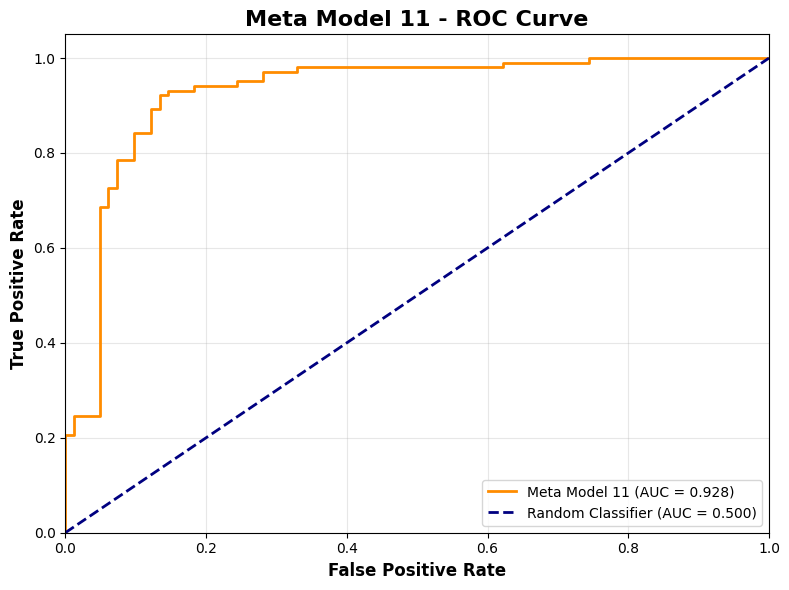


Meta Model 11 ROC AUC Score: 0.928
Excellent performance!


In [185]:
meta_model_11_fpr, meta_model_11_tpr, meta_model11_threshold = plot_roc_curve(y_test, meta_proba_11, model_name="Meta Model 11")

# Ensemble with Default Parameters and Catboost

## Meta Model 12

In [186]:
tree_ensemble_3 = VotingClassifier(
    estimators=[
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('rf', RandomForestClassifier(n_jobs=-1,random_state=42)),
        ('xgb', XGBClassifier(device='cuda',random_state=42)),
        ('lgbm', LGBMClassifier(device='gpu',learning_rate=0.01,random_state=42,verbose=-1))
    ],
    voting='soft',  # Use probabilities for smoother averaging
    n_jobs=-1
)

In [187]:
linear_ensemble_3 = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('knn', KNeighborsClassifier()),
        ('svc', SVC(probability=True, random_state=42))
    ],
    voting='soft',
    n_jobs=-1
)

In [188]:
tree_ensemble_3.fit(X_train, y_train)
linear_ensemble_3.fit(X_train, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression(random_state=42)),
                             ('knn', KNeighborsClassifier()),
                             ('svc', SVC(probability=True, random_state=42))],
                 n_jobs=-1, voting='soft')

In [189]:
# Use predicted probabilities as input features to meta learner
tree_pred_train_3 = tree_ensemble_3.predict_proba(X_train)[:, 1]
linear_pred_train_3 = linear_ensemble_3.predict_proba(X_train)[:, 1]

tree_pred_test_3 = tree_ensemble_3.predict_proba(X_test)[:, 1]
linear_pred_test_3 = linear_ensemble_3.predict_proba(X_test)[:, 1]

# Stack them horizontally as new features
meta_X_train_6 = np.column_stack((catboost_pred_train, tree_pred_train_3, linear_pred_train_3))
meta_X_test_6 = np.column_stack((catboost_pred_test, tree_pred_test_3, linear_pred_test_3))

In [190]:
meta_model_12 = LogisticRegression(max_iter=1000, random_state=42)
meta_model_12.fit(meta_X_train_6, y_train)

meta_pred_12 = meta_model_12.predict(meta_X_test_6)
meta_proba_12 = meta_model_12.predict_proba(meta_X_test_6)[:, 1]

In [191]:
print(classification_report(y_test, meta_pred_12))

              precision    recall  f1-score   support

           0       0.84      0.85      0.85        82
           1       0.88      0.87      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



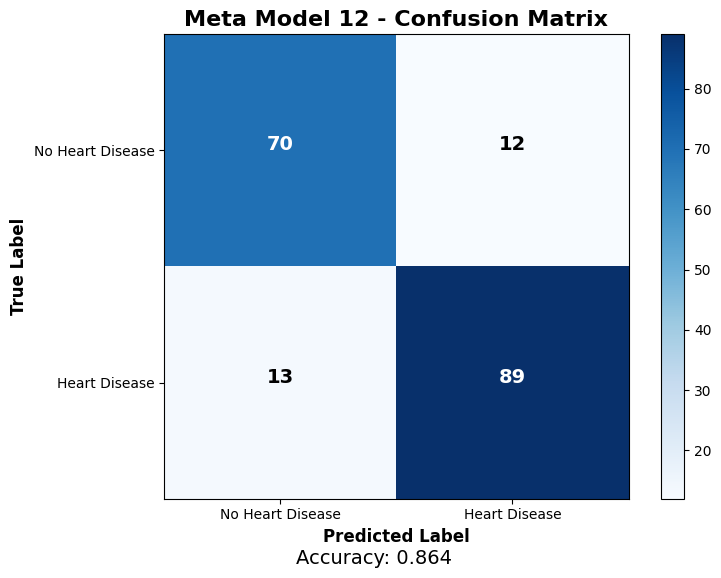


Meta Model 12 Performance:
True Negatives: 70
False Positives: 12
False Negatives: 13
True Positives: 89
Accuracy: 0.864
Precision: 0.881
Recall: 0.873
F1-Score: 0.877


In [192]:
meta_model_12_cm, meta_model_12_accuracy = plot_confusion_matrix(y_test, meta_pred_12, model_name="Meta Model 12")

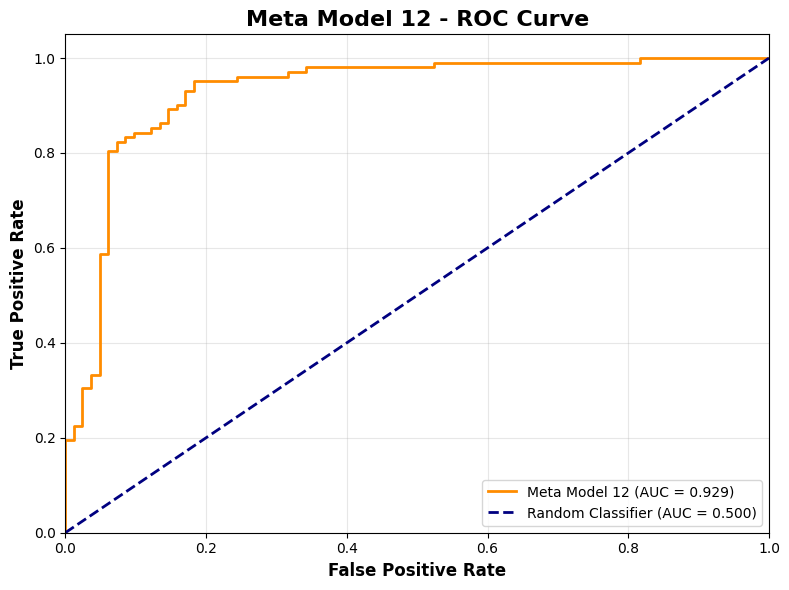


Meta Model 12 ROC AUC Score: 0.929
Excellent performance!


In [193]:
meta_model_12_fpr, meta_model_12_tpr, meta_model12_threshold = plot_roc_curve(y_test, meta_proba_12, model_name="Meta Model 12")

# Ensemble with boosting ensemble

## Meta Model 13

In [194]:
tree_ensemble_4 = VotingClassifier(
    estimators=[
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('rf', RandomForestClassifier(n_jobs=-1,random_state=42)),
    ],
    voting='soft',  # Use probabilities for smoother averaging
    n_jobs=-1
)

In [195]:
boost_ensemble = VotingClassifier(
    estimators = [
        ('xgb', XGBClassifier(device='cuda',random_state=42)),
        ('lgbm', LGBMClassifier(device='gpu',learning_rate=0.01,random_state=42,verbose=-1)),
        ('cat', CatBoostClassifier(task_type='GPU',random_state=42))
    ],
    voting='soft',
    n_jobs=-1
)

In [196]:
tree_ensemble_4.fit(X_train, y_train)
boost_ensemble.fit(X_train, y_train)


[CV] END C=100, l1_ratio=0.9, max_iter=500, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=100, l1_ratio=0.9, max_iter=500, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=100, l1_ratio=0.9, max_iter=500, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=100, l1_ratio=0.9, max_iter=500, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=100, l1_ratio=0.9, max_iter=1000, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=100, l1_ratio=0.9, max_iter=1000, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=100, l1_ratio=0.9, max_iter=1000, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END C=100, l1_ratio=0.9, max_iter=1000, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=100, l1_ratio=0.9, max_iter=1000, penalty=l1, solver=saga; total time=   0.0s
[CV] END C=100, l1_ratio=0.9, max_iter=1000, penalty=elasticnet, solver=saga; total time=   0.0s
Learning rate set to 0.034289
0:	learn: 0.6709265	total: 1.84s	remaining: 30

VotingClassifier(estimators=[('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None,
                                            device='cuda',
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_...
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=42, ...)),
                             ('lgbm',
                              LGBMClassifier(device='gpu', learning_rate=0.01,
                                             random_state=42, verbose=-1)),
                             ('cat',
                              <catboost.core.CatBoostClassifier object at 0x7e4e7f5b27d0>)],
                 n_jobs=-1, voting='soft')

In [197]:
# Use predicted probabilities as input features to meta learner
tree_pred_train_4 = tree_ensemble_4.predict_proba(X_train)[:, 1]
boost_pred_train = boost_ensemble.predict_proba(X_train)[:, 1]

tree_pred_test_4 = tree_ensemble_4.predict_proba(X_test)[:, 1]
boost_pred_test = boost_ensemble.predict_proba(X_test)[:, 1]

# Stack them horizontally as new features
meta_X_train_7 = np.column_stack((boost_pred_train, tree_pred_train_4, linear_pred_train_3))
meta_X_test_7 = np.column_stack((boost_pred_test, tree_pred_test_4, linear_pred_test_3))

In [198]:
meta_model_13 = LogisticRegression(max_iter=1000, random_state=42)
meta_model_13.fit(meta_X_train_7, y_train)

meta_pred_13 = meta_model_13.predict(meta_X_test_7)
meta_proba_13 = meta_model_13.predict_proba(meta_X_test_7)[:, 1]

In [199]:
print(classification_report(y_test, meta_pred_13))

              precision    recall  f1-score   support

           0       0.83      0.84      0.84        82
           1       0.87      0.86      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



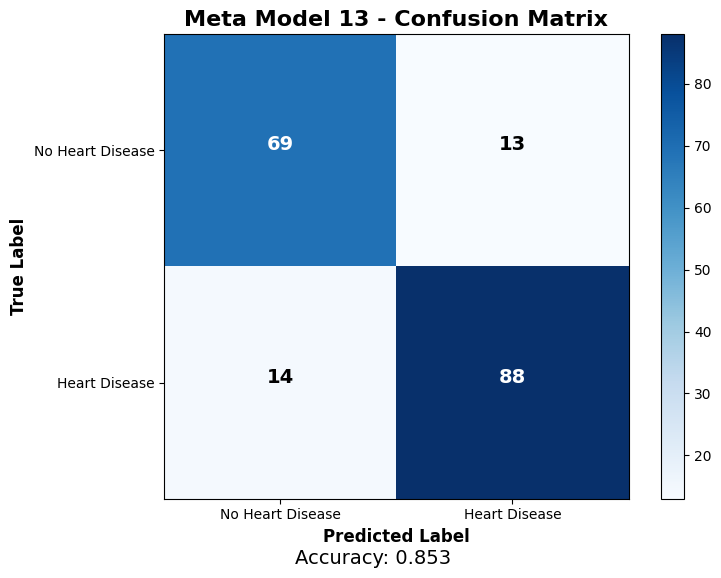


Meta Model 13 Performance:
True Negatives: 69
False Positives: 13
False Negatives: 14
True Positives: 88
Accuracy: 0.853
Precision: 0.871
Recall: 0.863
F1-Score: 0.867


In [200]:
meta_model_13_cm, meta_model_13_accuracy = plot_confusion_matrix(y_test, meta_pred_13, model_name="Meta Model 13")

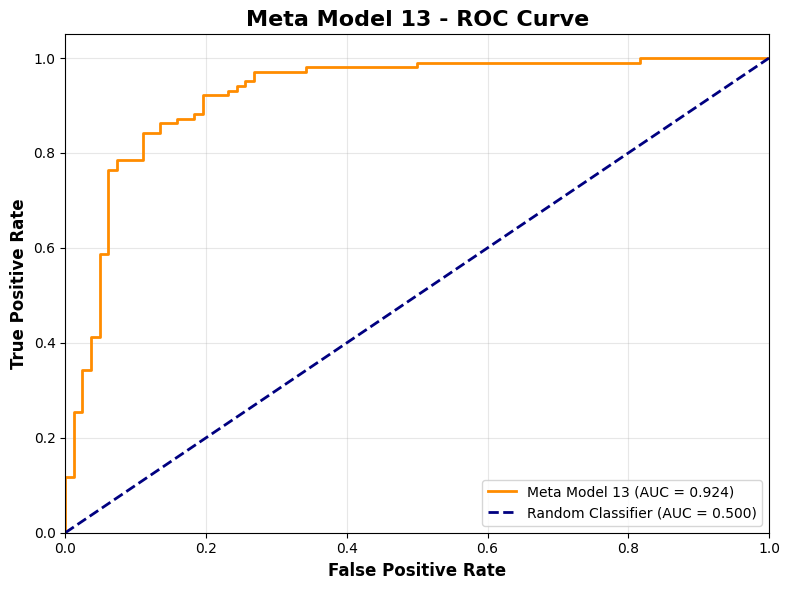


Meta Model 13 ROC AUC Score: 0.924
Excellent performance!


In [201]:
meta_model_13_fpr, meta_model_13_tpr, meta_model13_threshold = plot_roc_curve(y_test, meta_proba_13, model_name="Meta Model 13")